# راهنمای جامع کتابخانه OpenCV

## مقدمه

OpenCV (Open Source Computer Vision Library) یکی از محبوب‌ترین و قدرتمندترین کتابخانه‌های بینایی کامپیوتر است که توسط Intel در سال 1999 توسعه داده شد. این کتابخانه شامل بیش از 2500 الگوریتم بهینه شده برای پردازش تصویر، بینایی کامپیوتر، یادگیری ماشین و پردازش ویدئو است.

### ویژگی‌های کلیدی OpenCV:
- پشتیبانی از زبان‌های مختلف برنامه‌نویسی (Python, C++, Java)
- پردازش تصاویر و ویدئوها
- تشخیص اشیاء و چهره
- ردیابی اشیاء
- یادگیری ماشین
- پردازش تصاویر سه‌بعدی

### کاربردهای عملی OpenCV:

####  **پزشکی و سلامت**
- تشخیص تومورها در تصاویر پزشکی (MRI, CT Scan)
- تحلیل تصاویر اشعه ایکس
- تشخیص بیماری‌های چشمی
- پردازش تصاویر میکروسکوپی

####  **خودروهای خودران و حمل‌ونقل**
- تشخیص علائم راهنمایی و رانندگی
- شناسایی خط‌های جاده
- تشخیص عابران پیاده
- پارک خودکار
- کنترل سرعت تطبیقی

####  **صنعت و تولید**
- کنترل کیفیت محصولات
- تشخیص نقص در خط تولید
- رباتیک صنعتی
- بازرسی خودکار

####  **امنیت و نظارت**
- سیستم‌های تشخیص چهره
- تشخیص حرکات مشکوک
- شمارش افراد
- کنترل دسترسی

####  **فناوری موبایل و وب**
- فیلترهای واقعیت افزوده (AR)
- اسکن کدهای QR و بارکد
- تشخیص متن (OCR)
- ویرایش تصاویر خودکار

####  **بازی و سرگرمی**
- کنترل بازی با حرکات بدن
- تشخیص ژست‌ها
- واقعیت مجازی (VR)

####  **کشاورزی هوشمند**
- تشخیص آفات گیاهان
- نظارت بر رشد محصولات
- شمارش میوه‌ها
- تحلیل سلامت خاک

---

## نصب OpenCV

### روش اول: نصب با استفاده از pip

ساده‌ترین روش نصب OpenCV استفاده از pip است:

In [ ]:
!pip install opencv-python
!pip install opencv-contrib-python

### روش دوم: نصب با استفاده از conda

اگر از Anaconda یا Miniconda استفاده می‌کنید:

In [ ]:
!conda install -c conda-forge opencv
!conda install opencv

### تفاوت بین opencv-python و opencv-contrib-python:

- **opencv-python**: شامل ماژول‌های اصلی و پایه OpenCV
- **opencv-contrib-python**: شامل ماژول‌های اضافی و تجربی OpenCV

برای یادگیری و پروژه‌های عمومی، نسخه opencv-python کافی است، اما برای پروژه‌های پیشرفته‌تر توصیه می‌شود از opencv-contrib-python استفاده کنید.

## تست نصب OpenCV

In [ ]:
import cv2
import numpy as np

print(f"نسخه OpenCV: {cv2.__version__}")

print(f"پشتیبانی از GUI: {hasattr(cv2, 'imshow')}")

print(f"تعداد هسته‌های CPU: {cv2.getNumberOfCPUs()}")

نسخه OpenCV: 4.7.0
پشتیبانی از GUI: True
تعداد هسته‌های CPU: 12


## لینک‌های مفید و مستندات

### مستندات رسمی OpenCV:
- **وبسایت اصلی**: [https://opencv.org/](https://opencv.org/)
- **مستندات Python**: [https://docs.opencv.org/master/](https://docs.opencv.org/master/)
- **آموزش‌های OpenCV**: [https://docs.opencv.org/master/d9/df8/tutorial_root.html](https://docs.opencv.org/master/d9/df8/tutorial_root.html)

### منابع یادگیری:
- **GitHub Repository**: [https://github.com/opencv/opencv](https://github.com/opencv/opencv)
- **OpenCV Courses**: [https://opencv.org/courses/](https://opencv.org/courses/)
- **Community Forum**: [https://forum.opencv.org/](https://forum.opencv.org/)

### API Reference:
- **Python API**: [https://docs.opencv.org/master/d6/d00/tutorial_py_root.html](https://docs.opencv.org/master/d6/d00/tutorial_py_root.html)
- **Functions Index**: [https://docs.opencv.org/master/genindex.html](https://docs.opencv.org/master/genindex.html)

> **نکته مهم**: این لینک‌ها همیشه به‌روز هستند و حتی اگر این راهنما قدیمی شود، می‌توانید از آن‌ها برای دسترسی به جدیدترین اطلاعات استفاده کنید.

## وارد کردن کتابخانه‌های مورد نیاز

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.patches as patches
from IPython.display import Image, display
import os
import urllib.request
from PIL import Image as PILImage, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

def fix_persian_text(text):
    """تابع برای رفع مشکل جهت متن فارسی در نمودارها"""
    try:
        reshaped_text = arabic_reshaper.reshape(text)
        display_text = get_display(reshaped_text)
        return display_text
    except:
        return text

try:
    import arabic_reshaper
    from bidi.algorithm import get_display
except ImportError:
    print("در حال نصب کتابخانه‌های مورد نیاز...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "arabic-reshaper", "python-bidi"])
    import arabic_reshaper
    from bidi.algorithm import get_display

print(" کتابخانه‌ها با موفقیت وارد شدند!")
print(f" نسخه OpenCV: {cv2.__version__}")
print(f" نسخه NumPy: {np.__version__}")

✅ کتابخانه‌ها با موفقیت وارد شدند!
📌 نسخه OpenCV: 4.7.0
📌 نسخه NumPy: 1.26.4


## مفاهیم پایه OpenCV

### 1. خواندن و نمایش تصویر

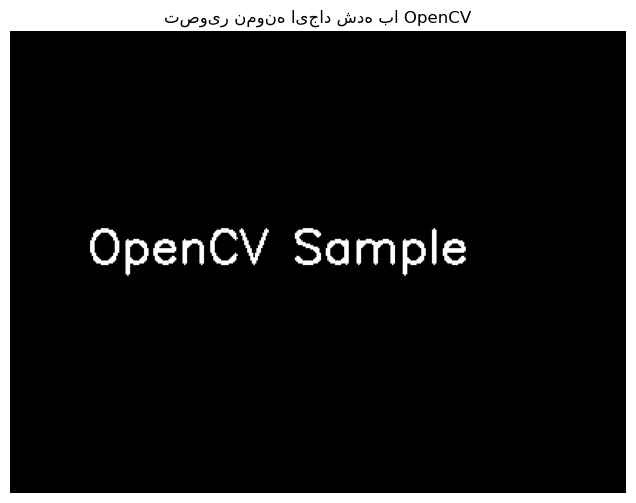

ابعاد تصویر: (300, 400, 3)
نوع داده: uint8


In [ ]:
height, width = 300, 400
blank_image = np.zeros((height, width, 3), dtype=np.uint8)

cv2.putText(blank_image, 'OpenCV Sample', (50, 150), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(blank_image, cv2.COLOR_BGR2RGB))
plt.title('تصویر نمونه ایجاد شده با OpenCV')
plt.axis('off')
plt.show()

print(f"ابعاد تصویر: {blank_image.shape}")
print(f"نوع داده: {blank_image.dtype}")

### 2. تبدیل فضای رنگی

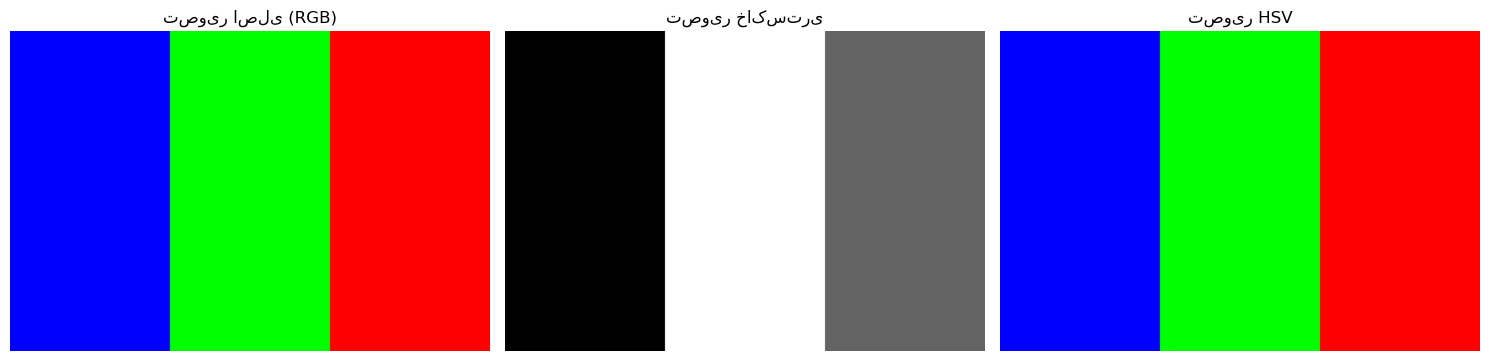

In [ ]:
color_image = np.zeros((200, 300, 3), dtype=np.uint8)
color_image[:, :100] = [255, 0, 0] 
color_image[:, 100:200] = [0, 255, 0] 
color_image[:, 200:] = [0, 0, 255]

gray_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)

hsv_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2HSV)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('تصویر اصلی (RGB)')
axes[0].axis('off')

axes[1].imshow(gray_image, cmap='gray')
axes[1].set_title('تصویر خاکستری')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB))
axes[2].set_title('تصویر HSV')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 3. عملیات پایه پردازش تصویر

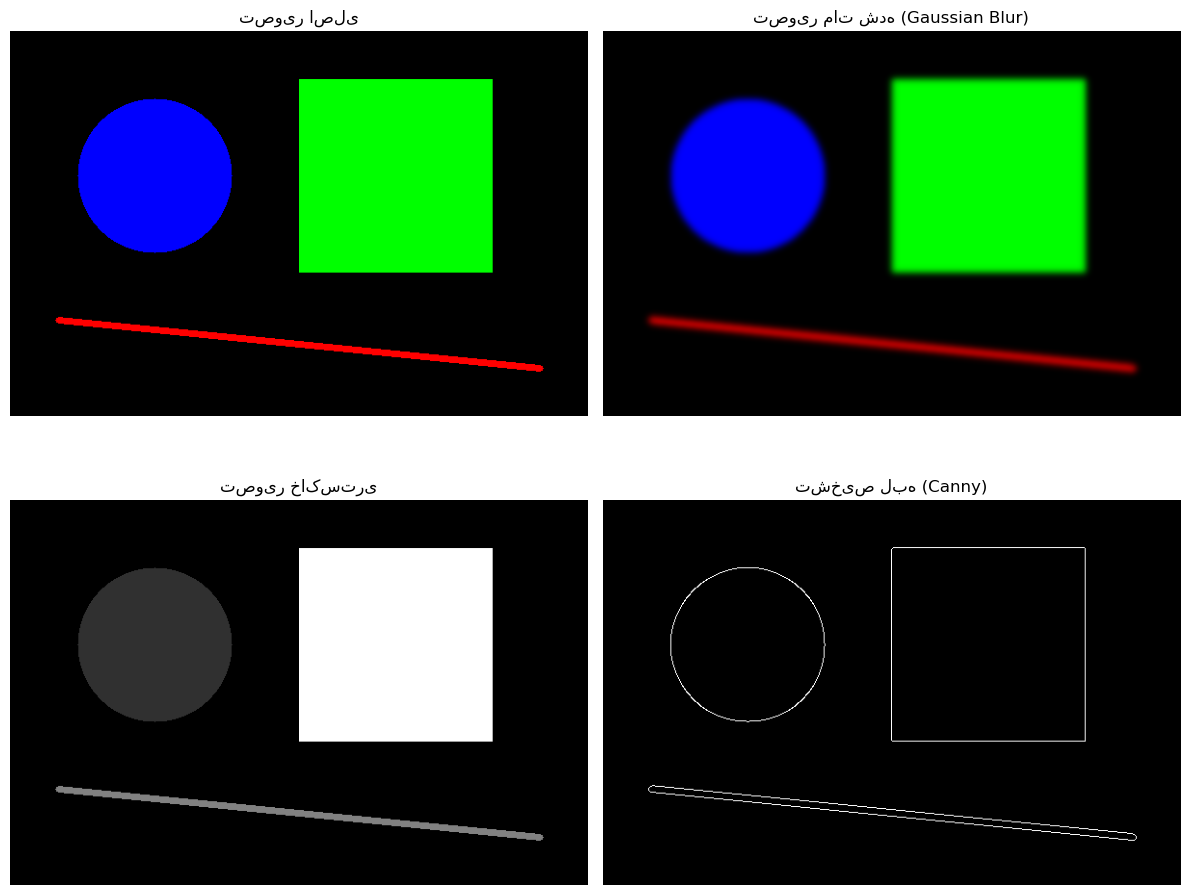

In [ ]:
sample_image = np.zeros((400, 600, 3), dtype=np.uint8)

cv2.circle(sample_image, (150, 150), 80, (255, 0, 0), -1)

cv2.rectangle(sample_image, (300, 50), (500, 250), (0, 255, 0), -1)

cv2.line(sample_image, (50, 300), (550, 350), (0, 0, 255), 5)

blurred = cv2.GaussianBlur(sample_image, (21, 21), 0)

gray = cv2.cvtColor(sample_image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))
axes[0,0].set_title('تصویر اصلی')
axes[0,0].axis('off')

axes[0,1].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
axes[0,1].set_title('تصویر مات شده (Gaussian Blur)')
axes[0,1].axis('off')

axes[1,0].imshow(gray, cmap='gray')
axes[1,0].set_title('تصویر خاکستری')
axes[1,0].axis('off')

axes[1,1].imshow(edges, cmap='gray')
axes[1,1].set_title('تشخیص لبه (Canny)')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

## عملیات مورفولوژیکی

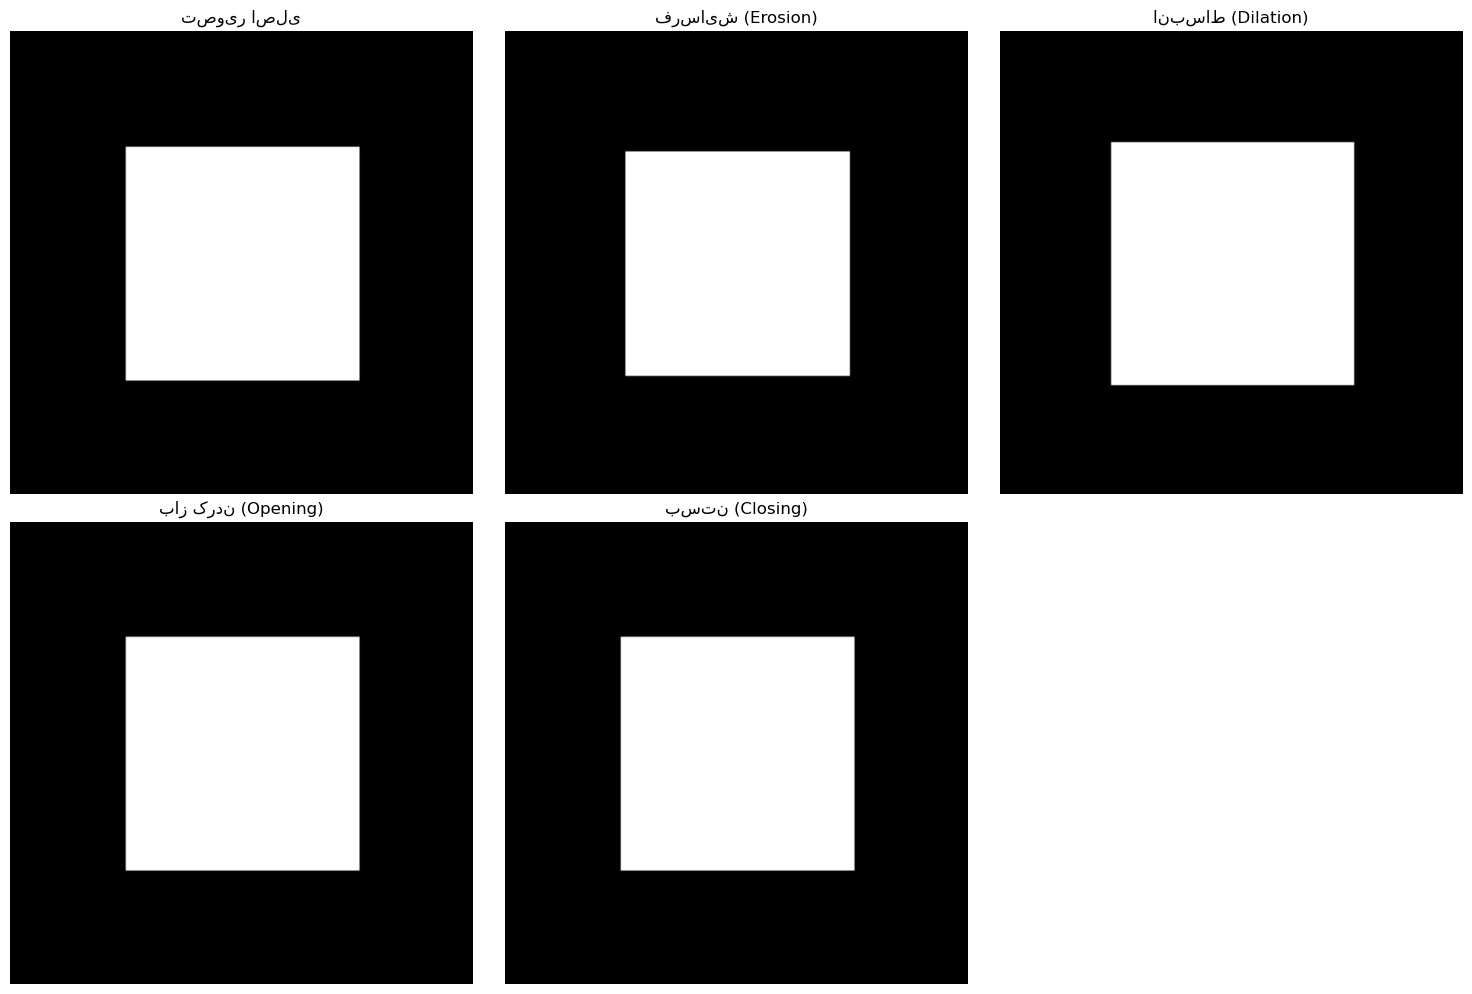

In [ ]:
binary_image = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(binary_image, (50, 50), (150, 150), 255, -1)

kernel = np.ones((5, 5), np.uint8)

erosion = cv2.erode(binary_image, kernel, iterations=1)
dilation = cv2.dilate(binary_image, kernel, iterations=1)
opening = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(binary_image, cmap='gray')
axes[0,0].set_title('تصویر اصلی')
axes[0,0].axis('off')

axes[0,1].imshow(erosion, cmap='gray')
axes[0,1].set_title('فرسایش (Erosion)')
axes[0,1].axis('off')

axes[0,2].imshow(dilation, cmap='gray')
axes[0,2].set_title('انبساط (Dilation)')
axes[0,2].axis('off')

axes[1,0].imshow(opening, cmap='gray')
axes[1,0].set_title('باز کردن (Opening)')
axes[1,0].axis('off')

axes[1,1].imshow(closing, cmap='gray')
axes[1,1].set_title('بستن (Closing)')
axes[1,1].axis('off')

axes[1,2].remove()

plt.tight_layout()
plt.show()

## فیلترهای مختلف

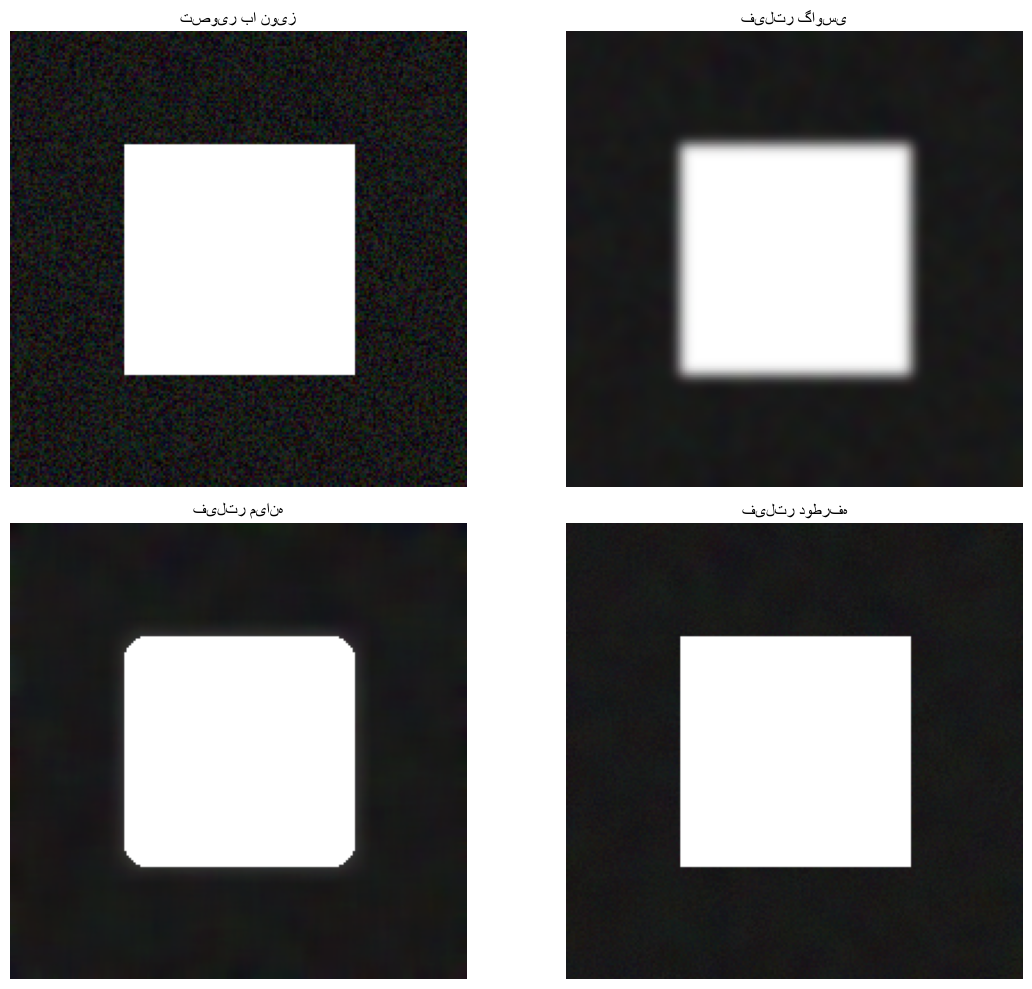

In [ ]:
clean_image = np.zeros((200, 200, 3), dtype=np.uint8)
cv2.rectangle(clean_image, (50, 50), (150, 150), (255, 255, 255), -1)

noise = np.random.randint(0, 50, clean_image.shape, dtype=np.uint8)
noisy_image = cv2.add(clean_image, noise)

gaussian_filtered = cv2.GaussianBlur(noisy_image, (15, 15), 0)
median_filtered = cv2.medianBlur(noisy_image, 15)
bilateral_filtered = cv2.bilateralFilter(noisy_image, 15, 50, 50)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].imshow(cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB))
axes[0,0].set_title('تصویر با نویز')
axes[0,0].axis('off')

axes[0,1].imshow(cv2.cvtColor(gaussian_filtered, cv2.COLOR_BGR2RGB))
axes[0,1].set_title('فیلتر گاوسی')
axes[0,1].axis('off')

axes[1,0].imshow(cv2.cvtColor(median_filtered, cv2.COLOR_BGR2RGB))
axes[1,0].set_title('فیلتر میانه')
axes[1,0].axis('off')

axes[1,1].imshow(cv2.cvtColor(bilateral_filtered, cv2.COLOR_BGR2RGB))
axes[1,1].set_title('فیلتر دوطرفه')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

## تشخیص کانتور (Contour Detection)

کانتور 1: مساحت = 10057.00, محیط = 410.88
کانتور 2: مساحت = 15000.00, محیط = 500.00
کانتور 3: مساحت = 7704.00, محیط = 329.71


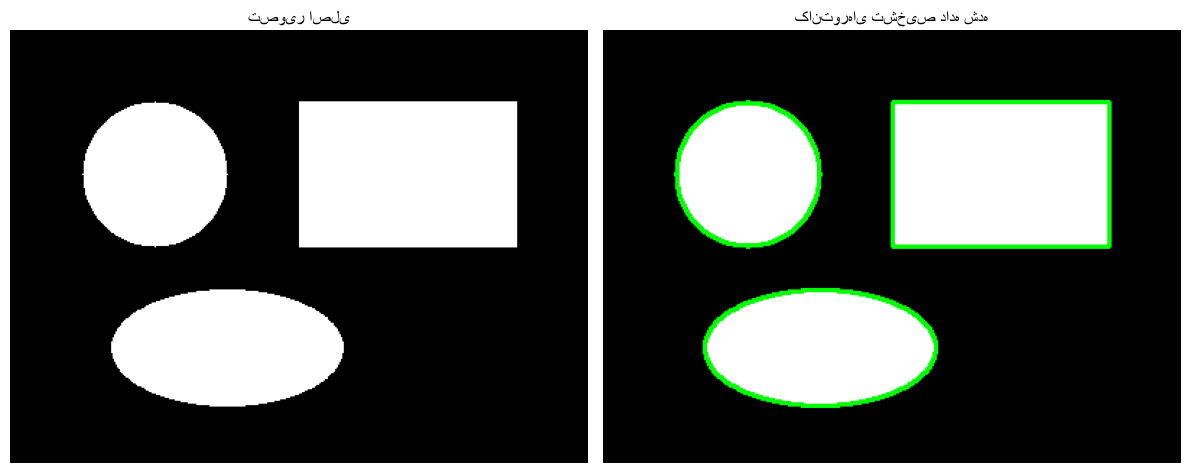

تعداد کانتورهای یافت شده: 3


In [ ]:
contour_image = np.zeros((300, 400), dtype=np.uint8)

cv2.circle(contour_image, (100, 100), 50, 255, -1)
cv2.rectangle(contour_image, (200, 50), (350, 150), 255, -1)
cv2.ellipse(contour_image, (150, 220), (80, 40), 0, 0, 360, 255, -1)

contours, hierarchy = cv2.findContours(contour_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_display = cv2.cvtColor(contour_image, cv2.COLOR_GRAY2BGR)

cv2.drawContours(contour_display, contours, -1, (0, 255, 0), 2)

for i, contour in enumerate(contours):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    print(f"کانتور {i+1}: مساحت = {area:.2f}, محیط = {perimeter:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(contour_image, cmap='gray')
axes[0].set_title('تصویر اصلی')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(contour_display, cv2.COLOR_BGR2RGB))
axes[1].set_title('کانتورهای تشخیص داده شده')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"تعداد کانتورهای یافت شده: {len(contours)}")

## تبدیل هندسی (Geometric Transformations)

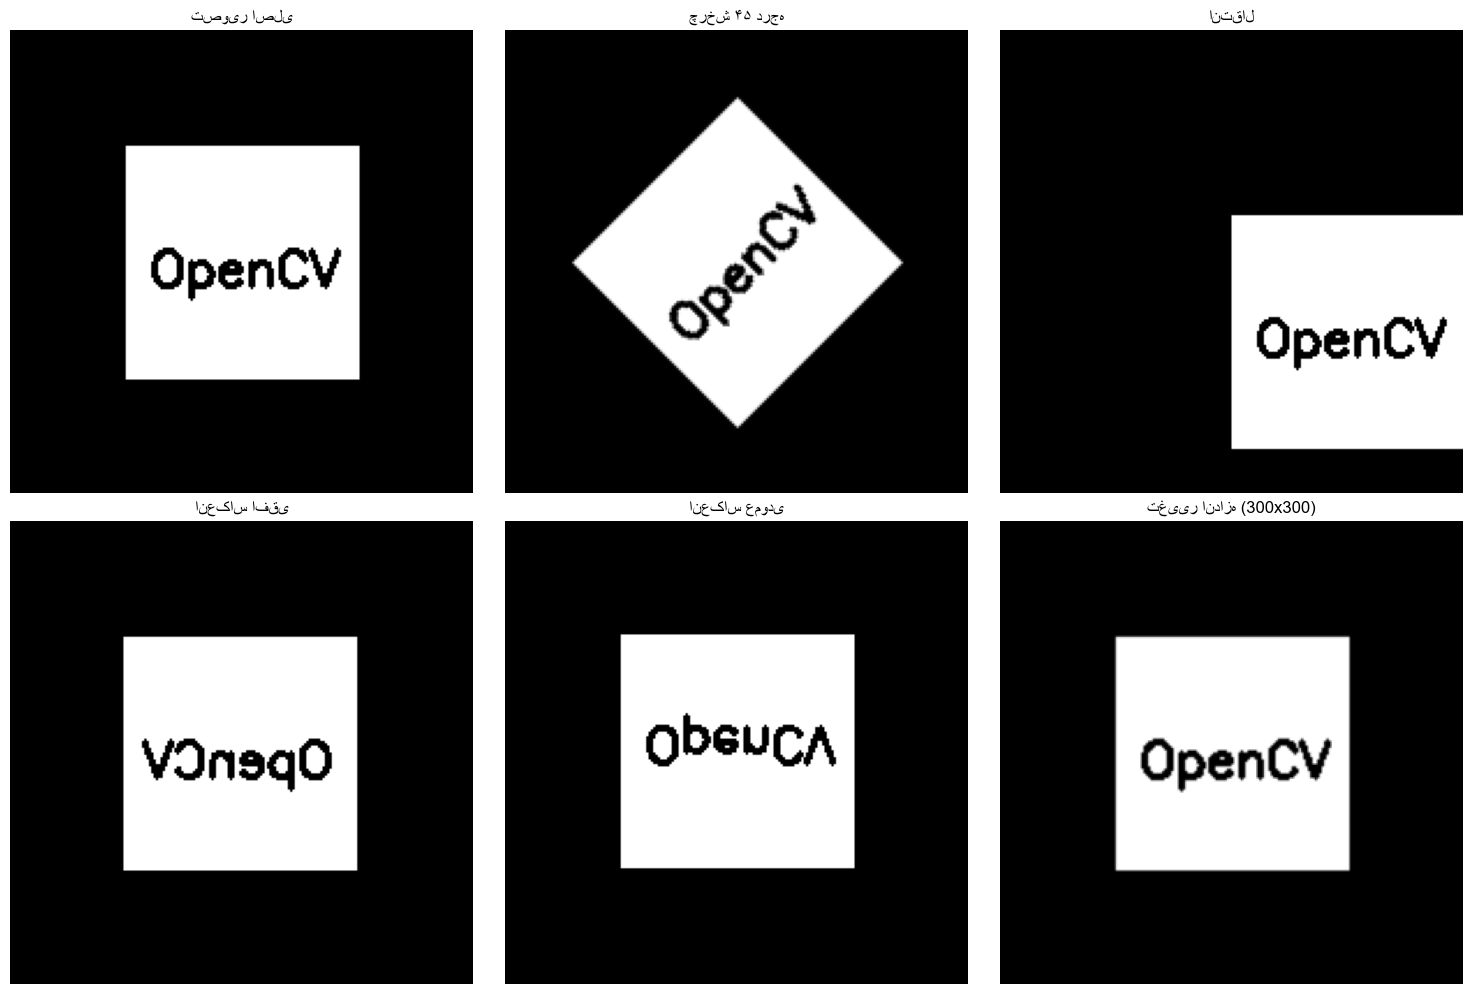

In [ ]:
original = np.zeros((200, 200, 3), dtype=np.uint8)
cv2.rectangle(original, (50, 50), (150, 150), (255, 255, 255), -1)
cv2.putText(original, 'OpenCV', (60, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

height, width = original.shape[:2]

rotation_matrix = cv2.getRotationMatrix2D((width/2, height/2), 45, 1)
rotated = cv2.warpAffine(original, rotation_matrix, (width, height))

translation_matrix = np.float32([[1, 0, 50], [0, 1, 30]])
translated = cv2.warpAffine(original, translation_matrix, (width, height))

resized = cv2.resize(original, (300, 300))

flipped_horizontal = cv2.flip(original, 1)

flipped_vertical = cv2.flip(original, 0)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0,0].set_title('تصویر اصلی')
axes[0,0].axis('off')

axes[0,1].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
axes[0,1].set_title('چرخش ۴۵ درجه')
axes[0,1].axis('off')

axes[0,2].imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
axes[0,2].set_title('انتقال')
axes[0,2].axis('off')

axes[1,0].imshow(cv2.cvtColor(flipped_horizontal, cv2.COLOR_BGR2RGB))
axes[1,0].set_title('انعکاس افقی')
axes[1,0].axis('off')

axes[1,1].imshow(cv2.cvtColor(flipped_vertical, cv2.COLOR_BGR2RGB))
axes[1,1].set_title('انعکاس عمودی')
axes[1,1].axis('off')

axes[1,2].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[1,2].set_title('تغییر اندازه (300x300)')
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

## نکات مهم و بهترین روش‌ها

### ۱. مدیریت حافظه
- همیشه از `dtype=np.uint8` برای تصاویر استفاده کنید
- برای تصاویر بزرگ، از تکنیک‌های بهینه‌سازی استفاده کنید

### ۲. فضای رنگی
- OpenCV از فضای رنگی BGR استفاده می‌کند (نه RGB)
- برای نمایش با matplotlib، باید BGR را به RGB تبدیل کنید

### ۳. عملکرد
- استفاده از NumPy operations جایگزین حلقه‌های Python
- استفاده از توابع OpenCV که بهینه شده‌اند

### ۴. مدیریت خطا
- همیشه وجود فایل را قبل از خواندن بررسی کنید
- از try-except برای مدیریت خطاها استفاده کنید

## مثال عملی: تشخیص رنگ

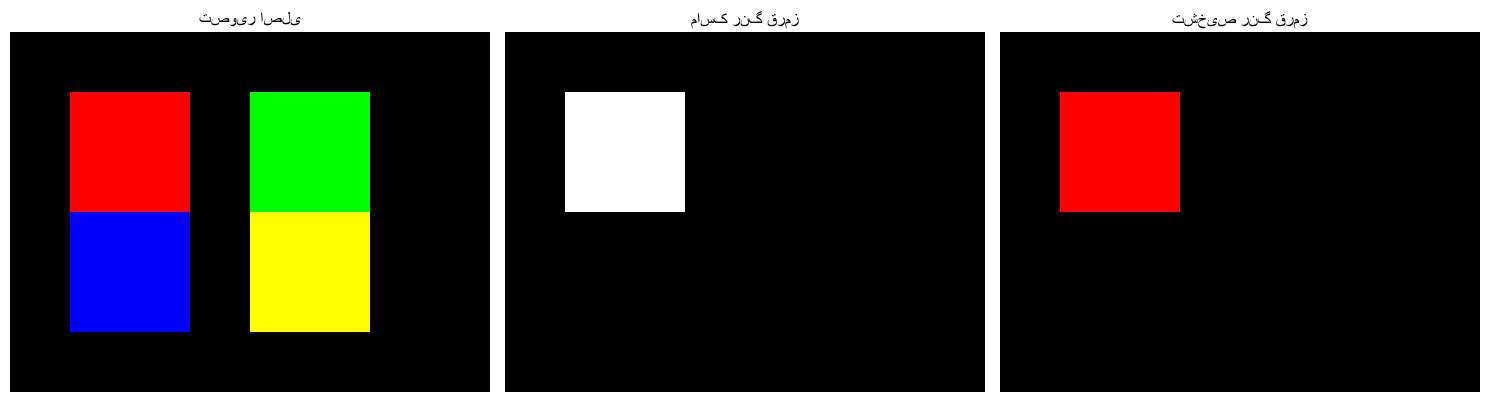

In [ ]:
color_test_image = np.zeros((300, 400, 3), dtype=np.uint8)

color_test_image[50:150, 50:150] = [0, 0, 255]      
color_test_image[50:150, 200:300] = [0, 255, 0]    
color_test_image[150:250, 50:150] = [255, 0, 0]    
color_test_image[150:250, 200:300] = [0, 255, 255] 

hsv_image = cv2.cvtColor(color_test_image, cv2.COLOR_BGR2HSV)

lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv_image, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv_image, lower_red2, upper_red2)
red_mask = cv2.bitwise_or(mask1, mask2)

red_detected = cv2.bitwise_and(color_test_image, color_test_image, mask=red_mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(color_test_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('تصویر اصلی')
axes[0].axis('off')

axes[1].imshow(red_mask, cmap='gray')
axes[1].set_title('ماسک رنگ قرمز')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(red_detected, cv2.COLOR_BGR2RGB))
axes[2].set_title('تشخیص رنگ قرمز')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## خلاصه و جمع‌بندی

در این راهنما با مفاهیم اصلی OpenCV آشنا شدیم:

### موارد پوشش داده شده:
1. **نصب OpenCV** با pip و conda
2. **خواندن و نمایش تصاویر**
3. **تبدیل فضای رنگی**
4. **عملیات پایه پردازش تصویر**
5. **عملیات مورفولوژیکی**
6. **فیلترهای مختلف**
7. **تشخیص کانتور**
8. **تبدیلات هندسی**
9. **تشخیص رنگ**

### گام‌های بعدی:
- یادگیری تشخیص چهره و اشیاء
- کار با ویدئو و دوربین
- الگوریتم‌های یادگیری ماشین در OpenCV
- پردازش تصاویر سه‌بعدی

### منابع مفید برای ادامه یادگیری:
- مستندات رسمی OpenCV
- پروژه‌های عملی در GitHub
- انجمن‌های OpenCV

---

**توجه**: این راهنما مقدماتی است و برای یادگیری عمیق‌تر، توصیه می‌شود به مستندات رسمی و منابع ذکر شده مراجعه کنید.